In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


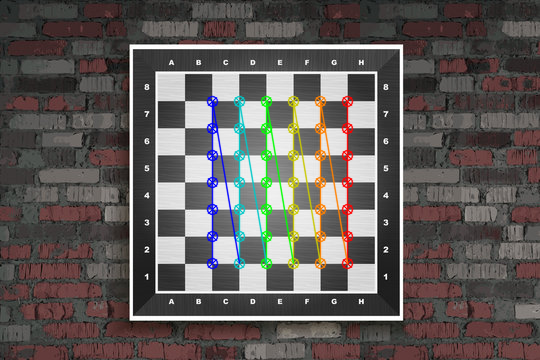

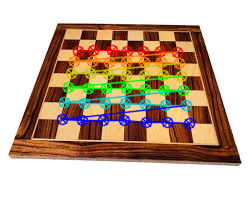

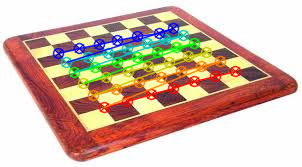

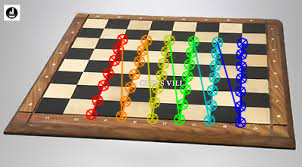

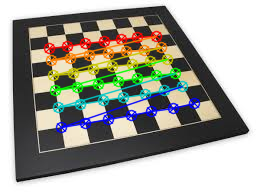

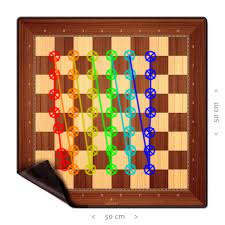

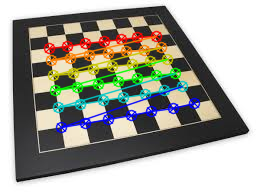

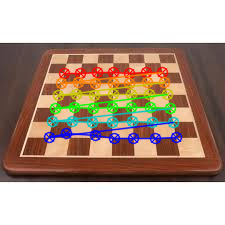

Camera matrix:
 [[1.33823774e+04 0.00000000e+00 2.70692124e+02]
 [0.00000000e+00 2.55364611e+03 2.79371760e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Distortion coefficients:
 [[-7.57937899e+01  1.40953077e+02 -2.27860904e+00 -2.90594116e-01
   5.61234061e+04]]


In [2]:
import cv2
import numpy as np
import glob
from google.colab.patches import cv2_imshow

# Prepare object points (0,0,0), (1,0,0), ..., (6,5,0)
objp = np.zeros((6*7,3), np.float32)
objp[:,:2] = np.mgrid[0:7,0:6].T.reshape(-1,2)

objpoints = []  # 3D points
imgpoints = []  # 2D points

# Load all images in the directory
images = glob.glob('/content/drive/MyDrive/opencv/ChessImages/*.jpg')

for fname in images:
    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, (7,6), None)

    if ret:
        objpoints.append(objp)
        imgpoints.append(corners)

        cv2.drawChessboardCorners(img, (7,6), corners, ret)
        cv2_imshow(img)
        cv2.waitKey(100)

# cv2.destroyAllWindows()

# Calibration
ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, gray.shape[::-1], None, None)

print("Camera matrix:\n", mtx)
print("Distortion coefficients:\n", dist)